# Potpuno povezana neuronska mreža

Predikcija srčane slabosti primenom metoda mašinskog učenja.

U ovoj svesci isti zadatak rešavamo potpuno povezanom neuronskom mrežom. Biramo arhitekturu mreže i ispitujemo kako na nju utiču tehnike regularizacije.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import metrics

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import regularizers

In [4]:
seed_value = 7

import os
os.environ['PYTHONHASHSEED'] = str(seed_value)

import random
random.seed(seed_value)

np.random.seed(seed_value)

import tensorflow as tf
tf.random.set_seed(seed_value)

In [5]:
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning)

# Učitavanje i pretprocesiranje skupa podataka

Podatke pripremamo na isti način i istom podelom kao u drugoj svesci, sa istom vrednošću parametra <code>random_state</code>, pa su skupovi identični i rezultati se mogu direktno porediti.

In [6]:
data = pd.read_csv('../data/heart.csv')

In [7]:
data['Cholesterol_izmeren'] = (data['Cholesterol'] != 0).astype(int)

In [9]:
data['Cholesterol'] = data['Cholesterol'].replace(0, data.loc[data['Cholesterol'] != 0, 'Cholesterol'].median())

In [10]:
data['RestingBP'] = data['RestingBP'].replace(0, data.loc[data['RestingBP'] != 0, 'RestingBP'].median())

In [11]:
data = pd.get_dummies(data, drop_first=True, dtype=int)

In [12]:
x = data.drop(labels=['HeartDisease'], axis=1)
y = data['HeartDisease']

Zarad lakše manipulacije podacima, prelazimo na NumPy matrice.

In [13]:
x = np.array(x)
y = np.array(y)

In [14]:
x.shape

(918, 16)

In [15]:
y.shape

(918,)

Podelu vršimo na skupove za treniranje, validaciju i testiranje, kao u drugoj svesci.

In [16]:
x_train_validation, x_test, y_train_validation, y_test = model_selection.train_test_split(x, y, test_size=0.2, stratify=y, random_state=7)

In [17]:
x_train, x_validation, y_train, y_validation = model_selection.train_test_split(x_train_validation, y_train_validation, train_size=0.8, stratify=y_train_validation, random_state=7)

In [18]:
x_train.shape

(587, 16)

In [19]:
x_validation.shape

(147, 16)

In [20]:
x_test.shape

(184, 16)

Vršimo standardizaciju atributa.

In [21]:
scaler = preprocessing.StandardScaler()

In [22]:
scaler.fit(x_train)

StandardScaler()

In [23]:
x_train = scaler.transform(x_train)
x_validation = scaler.transform(x_validation)
x_test = scaler.transform(x_test)

# Konstruisanje neuronske mreže

Pravimo potpuno povezanu neuronsku mrežu. Mreža će imati ulazni sloj, dva skrivena sloja sa, redom, 100 i 40 neurona, i izlazni sloj. Broj neurona ulaznog sloja odgovara broju atributa skupa podataka, a kako rešavamo problem binarne klasifikacije, izlazni sloj ima jedan neuron sa sigmoidnom aktivacijom. U skrivenim slojevima koristimo ReLU aktivaciju.

In [24]:
number_of_features = x.shape[1]
output_size = 1

In [25]:
model = Sequential()
model.add(Dense(units=100, input_shape=(number_of_features, ), activation='relu'))
model.add(Dense(units=40, activation='relu'))
model.add(Dense(units=output_size, activation='sigmoid'))

Opis konstruisane neuronske mreže:

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         4,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,781 (22.58 KB)

 Trainable params: 5,781 (22.58 KB)

 Non-trainable params: 0 (0.00 B)

# Treniranje neuronske mreže

Koristimo optimizator Adam, binarnu unakrsnu entropiju kao funkciju greške, a kako rešavamo klasifikacioni zadatak, za metriku biramo tačnost. Mrežu treniramo u 100 epoha sa paketićima veličine 32 instance, a kao validacione podatke prosleđujemo izdvojeni validacioni skup.

In [28]:
model.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [29]:
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_validation, y_validation), verbose=0)

Prikazujemo na istom grafiku vrednosti funkcije gubitka u toku treniranja mreže na skupu za treniranje i na validacionom skupu.

In [30]:
epochs = history.epoch
loss = history.history['loss']
validation_loss = history.history['val_loss']

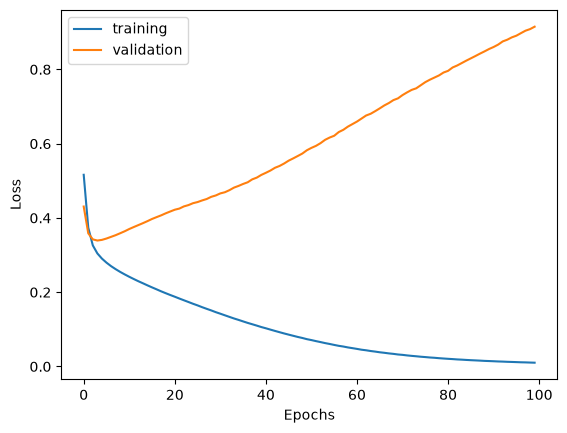

In [31]:
plt.plot(epochs, loss, label='training')
plt.plot(epochs, validation_loss, label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

Takođe, prikazujemo na istom grafiku tačnost klasifikacije u toku treniranja mreže na skupu za treniranje i na validacionom skupu.

In [32]:
acc = history.history['accuracy']
validation_acc = history.history['val_accuracy']

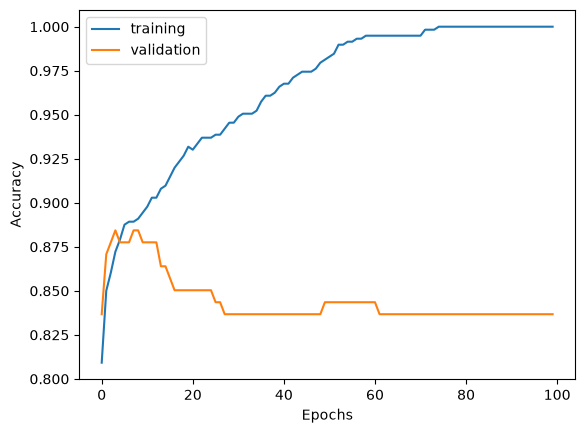

In [33]:
plt.plot(epochs, acc, label='training')
plt.plot(epochs, validation_acc, label='validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()

Grafici pokazuju tipičnu sliku preprilagođavanja. Greška na skupu za treniranje stalno opada i tačnost odlazi ka 1.00, dok greška na validacionom skupu posle nekoliko desetina epoha počinje da raste, a tačnost stagnira. Mreža sa 100 i 40 neurona ima nekoliko hiljada parametara, a skup za treniranje svega 587 instanci, pa je takav ishod očekivan.

# Izbor arhitekture

Zato poredimo pet arhitektura, od vrlo male do namerno prevelike. Sve koriste ReLU aktivaciju u skrivenim slojevima i sigmoidnu na izlazu, i sve se treniraju pod istim uslovima. Za svaku merimo tačnost na skupu za treniranje i na validacionom skupu.

In [34]:
arhitekture = [[8], [16], [32, 16], [64, 32], [100, 40]]

In [35]:
train_scores = []
validation_scores = []

for arhitektura in arhitekture:
    model = Sequential()
    model.add(Dense(units=arhitektura[0], input_shape=(number_of_features, ), activation='relu'))
    for units in arhitektura[1:]:
        model.add(Dense(units=units, activation='relu'))
    model.add(Dense(units=output_size, activation='sigmoid'))

    model.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=100, batch_size=32, verbose=0)

    train_scores.append(model.evaluate(x_train, y_train, verbose=0)[1])
    validation_scores.append(model.evaluate(x_validation, y_validation, verbose=0)[1])

In [37]:
rezultati_arhitektura = pd.DataFrame({'trening': train_scores, 'validacija': validation_scores},
                                     index=[str(a) for a in arhitekture])
rezultati_arhitektura

,trening,validacija
[8],0.885860,0.870748
[16],0.904600,0.877551
"[32, 16]",0.964225,0.829932
"[64, 32]",0.998296,0.843537
"[100, 40]",1.000000,0.850340


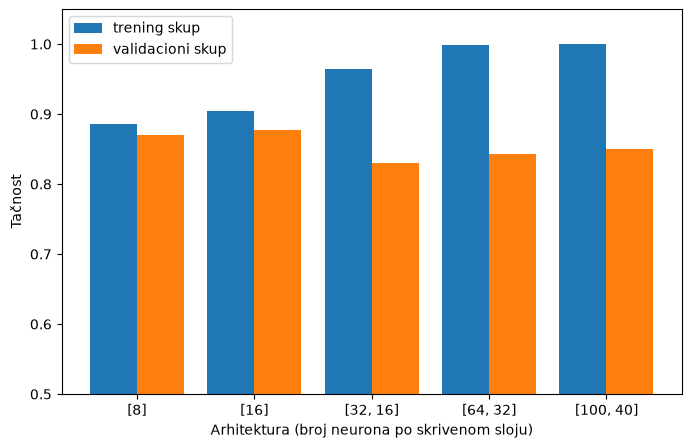

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(np.arange(len(arhitekture)) - 0.2, train_scores, width=0.4, label='trening skup')
plt.bar(np.arange(len(arhitekture)) + 0.2, validation_scores, width=0.4, label='validacioni skup')
plt.xticks(np.arange(len(arhitekture)), [str(a) for a in arhitekture])
plt.xlabel('Arhitektura (broj neurona po skrivenom sloju)')
plt.ylabel('Tačnost')
plt.ylim(0.5, 1.05)
plt.legend(loc='best')
plt.show()

Uočavamo pravilnost, što je mreža veća, to je tačnost na skupu za treniranje veća, a razlika u odnosu na validacioni skup šira. Najmanje mreže se ponašaju najstabilnije, jer imaju najmanje parametara koje treba naučiti iz 587 instanci.

# Regularizacija neuronske mreže

Sada uzimamo jednu srednju arhitekturu, sa 32 i 16 neurona, i poredimo četiri varijante:

* bez regularizacije, kao referentni model
* sa <code>Dropout</code> slojevima, koji tokom treniranja nasumično isključuju deo neurona i time sprečavaju mrežu da se previše osloni na pojedinačne neurone
* sa l2 kaznom nad težinama slojeva, što je ista ideja koju smo videli kod grebene regresije
* sa obe tehnike zajedno

## Bazni model (bez regularizacije)

In [39]:
model_bez = Sequential()
model_bez.add(Dense(units=32, input_shape=(number_of_features, ), activation='relu'))
model_bez.add(Dense(units=16, activation='relu'))
model_bez.add(Dense(units=output_size, activation='sigmoid'))

In [40]:
model_bez.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [42]:
history_bez = model_bez.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_validation, y_validation), verbose=0)

In [43]:
model_bez.evaluate(x_validation, y_validation, verbose=0)

[0.5352334380149841, 0.8367347121238708]

## Mreža sa Dropout slojevima

Parametrom se zadaje udeo neurona koji se isključuje, kod nas 30%.

In [44]:
model_dropout = Sequential()
model_dropout.add(Dense(units=32, input_shape=(number_of_features, ), activation='relu'))
model_dropout.add(Dropout(0.3))
model_dropout.add(Dense(units=16, activation='relu'))
model_dropout.add(Dropout(0.3))
model_dropout.add(Dense(units=output_size, activation='sigmoid'))

In [45]:
model_dropout.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [46]:
history_dropout = model_dropout.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_validation, y_validation), verbose=0)

In [47]:
model_dropout.evaluate(x_validation, y_validation, verbose=0)

[0.39497679471969604, 0.8707482814788818]

## Mreža sa l2 kaznom

Kazna se zadaje parametrom <code>kernel_regularizer</code> pojedinačnog sloja.

In [48]:
model_l2 = Sequential()
model_l2.add(Dense(units=32, input_shape=(number_of_features, ), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_l2.add(Dense(units=16, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_l2.add(Dense(units=output_size, activation='sigmoid'))

In [49]:
model_l2.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [50]:
history_l2 = model_l2.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_validation, y_validation), verbose=0)

In [51]:
model_l2.evaluate(x_validation, y_validation, verbose=0)

[0.4678981602191925, 0.8435373902320862]

## Mreža sa Dropout slojevima i l2 kaznom

In [52]:
model_dropout_l2 = Sequential()
model_dropout_l2.add(Dense(units=32, input_shape=(number_of_features, ), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_dropout_l2.add(Dropout(0.3))
model_dropout_l2.add(Dense(units=16, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_dropout_l2.add(Dropout(0.3))
model_dropout_l2.add(Dense(units=output_size, activation='sigmoid'))

In [53]:
model_dropout_l2.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [54]:
history_dropout_l2 = model_dropout_l2.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_validation, y_validation), verbose=0)

In [55]:
model_dropout_l2.evaluate(x_validation, y_validation, verbose=0)

[0.4190475046634674, 0.8707482814788818]

## Poređenje varijanti

In [56]:
rezultati_regularizacije = pd.DataFrame({
    'trening': [model_bez.evaluate(x_train, y_train, verbose=0)[1],
                model_dropout.evaluate(x_train, y_train, verbose=0)[1],
                model_l2.evaluate(x_train, y_train, verbose=0)[1],
                model_dropout_l2.evaluate(x_train, y_train, verbose=0)[1]],
    'validacija': [model_bez.evaluate(x_validation, y_validation, verbose=0)[1],
                   model_dropout.evaluate(x_validation, y_validation, verbose=0)[1],
                   model_l2.evaluate(x_validation, y_validation, verbose=0)[1],
                   model_dropout_l2.evaluate(x_validation, y_validation, verbose=0)[1]]},
    index=['bez regularizacije', 'dropout', 'l2', 'dropout i l2'])
rezultati_regularizacije

,trening,validacija
bez regularizacije,0.969336,0.836735
dropout,0.919932,0.870748
l2,0.921635,0.843537
dropout i l2,0.906303,0.870748


Kako regularizacija menja krive učenja vidi se na vrednostima funkcije gubitka na validacionom skupu:

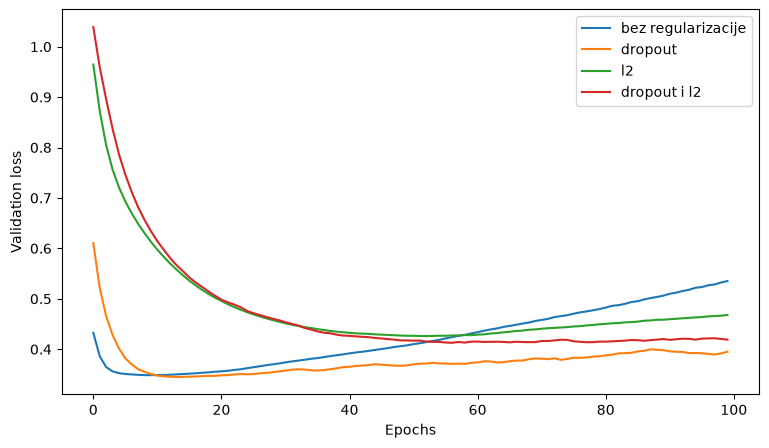

In [57]:
plt.figure(figsize=(9, 5))
plt.plot(history_bez.epoch, history_bez.history['val_loss'], label='bez regularizacije')
plt.plot(history_dropout.epoch, history_dropout.history['val_loss'], label='dropout')
plt.plot(history_l2.epoch, history_l2.history['val_loss'], label='l2')
plt.plot(history_dropout_l2.epoch, history_dropout_l2.history['val_loss'], label='dropout i l2')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend(loc='best')
plt.show()

Kod mreže bez regularizacije greška na validacionom skupu prvo opadne, a zatim počne da raste, što je znak da mreža uči šum iz skupa za treniranje. Regularizovane varijante taj rast zadržavaju ili ga bar znatno usporavaju, a razlika između tačnosti na skupu za treniranje i na validacionom skupu je manja.

# Konačna mreža

Najbolju tačnost na validacionom skupu imala je mala mreža sa jednim skrivenim slojem od 16 neurona (0.8776), a odmah do nje regularizovana mreža sa 32 i 16 neurona (0.8707). Biramo regularizovanu mrežu sa 32 i 16 neurona, sa <code>Dropout</code> slojevima i l2 kaznom, jer kod nje je razlika između tačnosti na skupu za treniranje i na validacionom skupu najmanja, pa se od nje očekuje najstabilnije ponašanje na novim podacima. Mrežu sada treniramo na uniji skupa za treniranje i validacionog skupa, a zatim je evaluiramo na skupu za testiranje, koji do sada nismo koristili.

In [58]:
x_train_validation_standardized = np.vstack([x_train, x_validation])
x_train_validation_standardized.shape

(734, 16)

In [59]:
y_train_validation = np.concatenate([y_train, y_validation])
y_train_validation.shape

(734,)

In [60]:
final_model = Sequential([Dense(units=32, input_shape=(number_of_features, ), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
                          Dropout(0.3),
                          Dense(units=16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
                          Dropout(0.3),
                          Dense(units=output_size, activation='sigmoid')
                         ])

In [61]:
final_model.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [62]:
history = final_model.fit(x_train_validation_standardized, y_train_validation, epochs=100, batch_size=32, verbose=0)

Vrednost funkcije gubitka i tačnost klasifikacije na skupu za treniranje i na skupu za testiranje:

In [63]:
train_scores = final_model.evaluate(x_train_validation_standardized, y_train_validation, verbose=0)

In [64]:
train_scores

[0.30090829730033875, 0.9114441275596619]

In [65]:
test_scores = final_model.evaluate(x_test, y_test, verbose=0)

In [66]:
test_scores

[0.3418270945549011, 0.875]

Izračunavamo predikcije mreže na skupu za testiranje. Mreža vraća verovatnoće pripadnosti pozitivnoj klasi, pa ih pragom 0.5 prevodimo u labele.

In [67]:
y_test_probabilities_predicted = final_model.predict(x_test, verbose=0)

In [68]:
y_test_predicted = (y_test_probabilities_predicted > 0.5).astype(int)

Ispisujemo klasifikacioni izveštaj.

In [69]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.88      0.83      0.86        82
           1       0.87      0.91      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184



Izračunavamo matricu konfuzije.

In [70]:
metrics.confusion_matrix(y_test, y_test_predicted)

array([[68, 14],
       [ 9, 93]])

# Zaključak

Veličina mreže je ovde najvažnija odluka. Sa 16 atributa i 587 instanci u skupu za treniranje, velike mreže samo nauče skup za treniranje napamet. Krive učenja jasno pokazuju preprilagođavanje, greška na skupu za treniranje opada, a na validacionom skupu posle nekog broja epoha počinje da raste. Regularizacija pomaže i ovde. <code>Dropout</code> i l2 kazna smanjuju razliku između tačnosti na skupu za treniranje i na validacionom skupu, a kriva greške na validacionom skupu prestaje da raste. Neuronska mreža na ovom skupu ne nadmašuje klasične modele iz druge sveske.